(streaming_tick_data)=

# Streaming variational inference on high-frequency tick data

:::{post} August 2026
:tags: variational inference, minibatch, out-of-core, hierarchical model, time series
:category: advanced, tutorial
:author: Yicheng Yang
:::

Exchanges publish per-trade archives — Binance, for instance, distributes
aggregate trades as daily and monthly files at
[data.binance.vision](https://data.binance.vision). Widen a pull across
symbols and months and the feature matrix can outgrow the RAM of an ordinary
workstation; at that point in-memory minibatching stops being an option. PyMC's
{func}`~pymc.Minibatch` randomly slices tensor *inputs*; it is not itself a
disk-backed reader, so it cannot help once the array no longer fits. This
notebook fits a hierarchical hurdle–Student-t model of *next-event price
moves* by streaming minibatches from disk with pymc-extras'
{class}`~pymc_extras.variational.dataloader.DataLoader`, on 300,000 synthetic
rows that are generated inside the notebook. It tries to teach three things:

1. **When minibatch VI is even valid.** Two acceptance gates that most
   time-series models fail — and a model class that passes both.
2. **The mechanics, end to end** on an archive small enough to rebuild here:
   an on-disk global shuffle, streaming ADVI with `total_size` rescaling, and
   what a stopping rule has to be able to see before it can fire.
3. **Honest reporting.** With the truth known, recovery is checkable — but only
   after a correction the fit forces on us: the cyclic replay puts the optimizer
   on an orbit, and the last iterate misses the truth by several of its own
   posterior standard deviations purely because of where in that orbit the step
   budget ended. Averaged over one full pass, every identified quantity lands
   inside 1.2. The widths themselves are a separate question this notebook
   cannot settle on one dataset, and it says so rather than certifying them.

The notebook runs in well under a minute on a laptop. Everything below executes on synthetic
data with known ground truth, which is what makes the recovery checks
possible: nothing here is a claim about any real market.

## Two gates: when minibatch VI is valid, and when it is worth it

Minibatch variational inference rests on one identity: if the likelihood
factors over rows given the parameters, then the batch log-likelihood scaled by
$N/B$ is an unbiased estimator of the full-data log-likelihood
{cite:p}`hoffman2013stochastic`. Two gates shaped this notebook's model — the
first is about *validity*, the second about whether streaming is doing any
real work — and they are worth internalizing before reaching for `total_size`
on your own data:

**Gate 1 — validity: the likelihood must factor over rows, and the batching
must weight every row equally.** No latent path coupling observations, no
label shared across rows, and every row given the same inclusion frequency by
the batching scheme (unequal inclusion breaks the plain $N/B$ rescaling). How
the batches are *drawn* is a separate matter that this gate does not settle:
fresh uniform batches make each step's scaled gradient conditionally unbiased
for the full-data objective — the identity above — while a fixed shuffled
order replayed every epoch visits each row once per pass, targets the same
finite sum, and yields cyclic rather than unbiased updates. This notebook does
the second, and returns to the distinction where the fit is described. The
factorization requirement is exactly why the classic
stochastic volatility model of the {ref}`stochastic_volatility` notebook
*cannot* be minibatched: its latent volatility path ties every observation to
its neighbours, so a random subset of rows does not carry $B/N$ of the
log-likelihood. Any model whose rows share one outcome (for example, every tick
of a match sharing the final result) fails the same gate through
pseudo-replication — the effective sample size is the number of outcomes, not
the number of rows.

**Gate 2 — non-triviality: no low-dimensional sufficient statistics.** This
one is not about validity but about honesty of the *showcase*: a Normal
likelihood with per-cell means and variances collapses to per-cell
$(\sum y, \sum y^2, n)$, so one linear scan computes the exact posterior
inputs and "streaming inference" degenerates into a glorified `groupby` —
valid, but theater. A hurdle alone does not rescue it — an observed Bernoulli
plus a Normal component still reduces to $(n_0, n_1, \sum y, \sum y^2)$. What
does break the collapse is the combination used below: a Student-t component
with an unknown $\nu$, and row-level continuous covariates entering through
nonlinear links, so no fixed-dimensional summary of the rows suffices.

The model below passes both gates. Each ingredient that gets it there is also
the standard choice for the feature it addresses, which is the argument for
it — not the synthetic data, which was written to contain those features in
the first place.

:::{include} ../extra_installs.md
:::

:::{note}
The {class}`~pymc_extras.variational.dataloader.DataLoader` merged into
pymc-extras after the v0.14.0 release, so it is not in a published version yet
and `pip install pymc-extras` will not provide it. The outputs stored in this
notebook were produced against the merge commit itself, which is also the
install line to use until the next release:

```
pip install "pymc-extras @ git+https://github.com/pymc-devs/pymc-extras@8db1880"
```

That pins pymc-extras `0.14.1.dev3+g8db1880d4`, and its own requirements pull
PyMC 6.2 and PyTensor 3.2 — the versions reported by the watermark at the
bottom of this page. Once the module ships, `pip install pymc-extras` will do.
:::

In [1]:
import gc
import logging
import os
import tempfile
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import pymc as pm
import pytensor.tensor as pt

from pymc_extras.variational.dataloader import DataLoader, parquet_source
from scipy import stats

In [2]:
%config InlineBackend.figure_format = 'retina'
RANDOM_SEED = 20260731
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
# the loss figures carry the fit story; keep the fit logger's lines out of the output
logging.getLogger("pymc").setLevel(logging.ERROR)
# pytensor's predictive path emits two benign internals warnings (a 0/0 inside its
# own allclose diagnostics; numba falling back to object mode for the python
# `random`); neither is actionable here, so they are filtered by origin
warnings.filterwarnings("ignore", category=RuntimeWarning, module=r"pytensor\.tensor\.type")
warnings.filterwarnings("ignore", message=r"Numba will use object mode")

## The model: hierarchical hurdle–Student-t next-event returns

One row is one trade-to-trade transition $i$ on symbol $s$ at UTC hour $h$:
the return $y_i = 10^4 \, (\log p_{i+1} - \log p_i)$ in basis points, and the
move indicator $m_i = \mathbb{1}[y_i \neq 0]$. Two consequences of indexing by
*events* rather than by clock time are worth stating before the algebra.

First, prices move on a discrete grid, so an exact-zero return is not a
measure-zero event the way it is for a continuous variable: consecutive trades
can and do leave the price where it was. A purely continuous likelihood puts
zero probability mass on that outcome, whatever share of the rows it turns out
to occupy. The fix is a hurdle: model *whether* the price moves separately
from *how far* it moves given that it does.

Second, each row is a transition between consecutive observed events, not a
fixed-duration return. So $1 - \pi$ is the probability that the next event
leaves the price unchanged, and $\sigma$ is the Student-t scale *conditional on
a move*. Neither is clock-time volatility: converting to a clock would
additionally require a model of event arrival times
{cite:p}`engle1998autoregressive`.

$$
\begin{aligned}
m_i &\sim \text{Bernoulli}(\pi_i) \\
y_i \mid m_i = 1 &\sim \text{StudentT}(\nu,\ \mu_i,\ \sigma_i) \\
\operatorname{logit} \pi_i &= \kappa_0 + b^{(\kappa)}_s
  + B(h)^\top\!\left(c + b^{(\pi h)}_s\right)
  + \lambda_a a_i + \lambda_q q_i \\
\log \sigma_i &= \alpha_0 + b^{(\alpha)}_s
  + B(h)^\top\!\left(g + b^{(\sigma h)}_s\right)
  + (\beta_a + b^{(\beta a)}_s)\, a_i + \beta_q q_i \\
\mu_i &= \theta_d\, d_i + \theta_r\, \text{ylag}_i
\end{aligned}
$$

The covariates are a simulated trade sign $d_i$, a notional-like $q_i$, an
activity-like $a_i$, and $\text{ylag}_i$, the most recent previous nonzero
return on that symbol. In the generator below they are drawn directly rather
than engineered from a trade tape: only $\text{ylag}$ is produced
sequentially, so it is the one covariate that could not see the future, and
$q$ and $a$ are standardized once over the whole sample. On a real archive
both would instead be trailing statistics built causally from the tape and
standardized with constants frozen on a burn-in window — a construction that
is out of scope here, and one that is easy to get subtly wrong. $B(h)$ is the first two sine/cosine harmonics of hour-of-day,
a low-order version of the Fourier encoding of intraday periodicity in
{cite:t}`andersen1997intraday`; heavy-tailed Student-t noise for returns goes
back at least to {cite:t}`bollerslev1987conditionally`. All symbol effects
$b_s \sim \mathcal{N}(0, \tau)$ are partially pooled {cite:p}`gelman2006data`,
so a thin symbol is pulled toward the global intraday shape where its own data
run out. They are parameterized
*centered*, deliberately: the non-centered trick pays off when groups are
data-poor, and the generator below gives every symbol at least several hundred
rows.
The degrees of freedom are
shared across symbols, parameterized $\nu = 1 + \operatorname{softplus}(\eta)$;
the floor of 1 rather than 2 leaves the support open to tails too heavy to
carry a finite variance. Be precise about what that buys: under
$\eta \sim \mathcal{N}(5, 1)$ the prior puts only about $4 \times 10^{-6}$ of
its mass on $\nu \le 2$, so this is a statement about support, not a serious
prior belief in infinite variance. The estimand below is chosen so that the
question does not arise at all.

The reported estimand is **event-return dispersion on the event clock**:
$\pi_{s,h}$ together with the conditional-move 90% half-width
$\sigma_{s,h} \cdot t^{-1}_{0.95}(\nu)$. A quantile is the safe choice here: it
stays finite for any $\nu > 0$, whereas a moment-based dispersion requires
$\nu > 2$ — a constraint the model does not impose, even though the generator
below happens to use $\nu = 3.5$.

## Synthetic data with known truth

Notebooks in this collection do not download data at build time, so the
executed path uses a seeded synthetic generator: the schema an exchange
archive would have after feature construction, a hurdle at exactly zero,
heavy conditional tails, and twelve symbols whose row counts span two orders
of magnitude, so the hierarchy has both data-rich and data-poor groups to work
with. Because the truth is known, recovery is checkable. Every
statement below about what the fit recovers is conditional on this generator;
none of it is a measurement of any market.

In [3]:
n_symbols = 12
counts = np.array(
    [90_700, 55_000, 40_000, 30_000, 24_000, 19_000, 15_000, 11_000, 8_000, 4_600, 1_800, 900]
)
thin = [10, 11]  # the two symbols with the least data

truth = {
    "kappa0": np.log(0.7 / 0.3),  # logit(0.7): see the annotation below
    "c": np.array([0.25, -0.15, 0.10, 0.05]),
    "lambda_a": 0.35,
    "lambda_q": 0.20,
    "alpha0": np.log(0.05),  # conditional-move scale, in basis points
    "g": np.array([0.20, -0.12, 0.08, 0.04]),
    "beta_a": 0.18,
    "beta_q": 0.12,
    "theta_d": 0.02,
    "theta_r": 0.25,
    "nu": 3.5,
}


def standardize(x, axis=0):
    return (x - x.mean(axis=axis, keepdims=True)) / x.std(axis=axis, keepdims=True)


z_truth = {
    "z_k": standardize(rng.standard_normal(n_symbols)),
    "z_ph": standardize(rng.standard_normal((n_symbols, 4))),
    "z_al": standardize(rng.standard_normal(n_symbols)),
    "z_sh": standardize(rng.standard_normal((n_symbols, 4))),
    "z_ba": standardize(rng.standard_normal(n_symbols)),
}

In [4]:
def hour_basis(hour):
    w = 2 * np.pi * np.asarray(hour, dtype=float) / 24.0
    return np.column_stack([np.sin(w), np.cos(w), np.sin(2 * w), np.cos(2 * w)])


sym = np.repeat(np.arange(n_symbols), counts)
n = len(sym)
hour = rng.integers(0, 24, size=n)
d = rng.choice([-1.0, 1.0], size=n)
a = standardize(rng.standard_normal(n))  # trailing activity (already standardized)
q = standardize(0.3 * a + np.sqrt(1 - 0.3**2) * rng.standard_normal(n))

B = hour_basis(hour)
logit_pi = (
    truth["kappa0"]
    + 0.30 * z_truth["z_k"][sym]
    + B @ truth["c"]
    + (B * (0.15 * z_truth["z_ph"][sym])).sum(1)
    + truth["lambda_a"] * a
    + truth["lambda_q"] * q
)
log_sigma = (
    truth["alpha0"]
    + 0.35 * z_truth["z_al"][sym]
    + B @ truth["g"]
    + (B * (0.12 * z_truth["z_sh"][sym])).sum(1)
    + (truth["beta_a"] + 0.10 * z_truth["z_ba"][sym]) * a
    + truth["beta_q"] * q
)

m = (rng.random(n) < 1 / (1 + np.exp(-logit_pi))).astype(np.int8)
t_draw = rng.standard_t(truth["nu"], size=n)

# sequential generation per symbol so ylag feeds back causally
y = np.zeros(n)
ylag = np.zeros(n)
sigma = np.exp(log_sigma)
for s in range(n_symbols):
    idx = np.flatnonzero(sym == s)
    last = 0.0
    for i in idx:
        ylag[i] = last
        if m[i]:
            y[i] = truth["theta_d"] * d[i] + truth["theta_r"] * last + sigma[i] * t_draw[i]
            last = y[i]

print(
    f"{n:,} rows, zero-move share {(m == 0).mean():.1%}, "
    f"median nonzero |y| {np.median(np.abs(y[m == 1])):.3f} bp, "
    f"corr(a, q) {np.corrcoef(a, q)[0, 1]:.2f}"
)

300,000 rows, zero-move share 32.1%, median nonzero |y| 0.041 bp, corr(a, q) 0.30


Each constant above is a setting, not a measurement, and it is worth reading
them the way one would read a specification for a simulator:

* `kappa0` = $\operatorname{logit}(0.7)$. If every other term in the logit were
  zero, the move probability would be 0.7. The harmonics, the covariates and
  the symbol effects all shift it, so the *realized* zero share is the number
  printed above, not $30\%$ by construction.
* `theta_r` $= 0.25$ imposes positive first-order dependence in the conditional
  location: the next move is generated partly from the previous nonzero one. It
  is a synthetic dependence parameter — note that the classical bid–ask bounce
  of {cite:t}`roll1984simple` runs the other way, inducing *negative* serial
  dependence, which this generator does not encode.
* `theta_d` $= 0.02$ is the coefficient on the simulated trade sign: holding
  everything else fixed, sign $+1$ versus $-1$ differs by 0.04 bp in
  conditional location.
* $a$ and $q$ are constructed with a target correlation of 0.3 rather than
  orthogonally, so the fit faces mildly collinear covariates instead of a
  textbook design; the realized sample correlation is in the printout above.
* `ylag` is generated per symbol in sequence, so row $i$ sees only the most
  recent previously generated nonzero move. That discipline applies to the lag
  construction; the standardization of $a$ and $q$ still uses full-sample
  constants, an offline simplification kept for readability.

With that in mind, here is the feature that forces the hurdle:

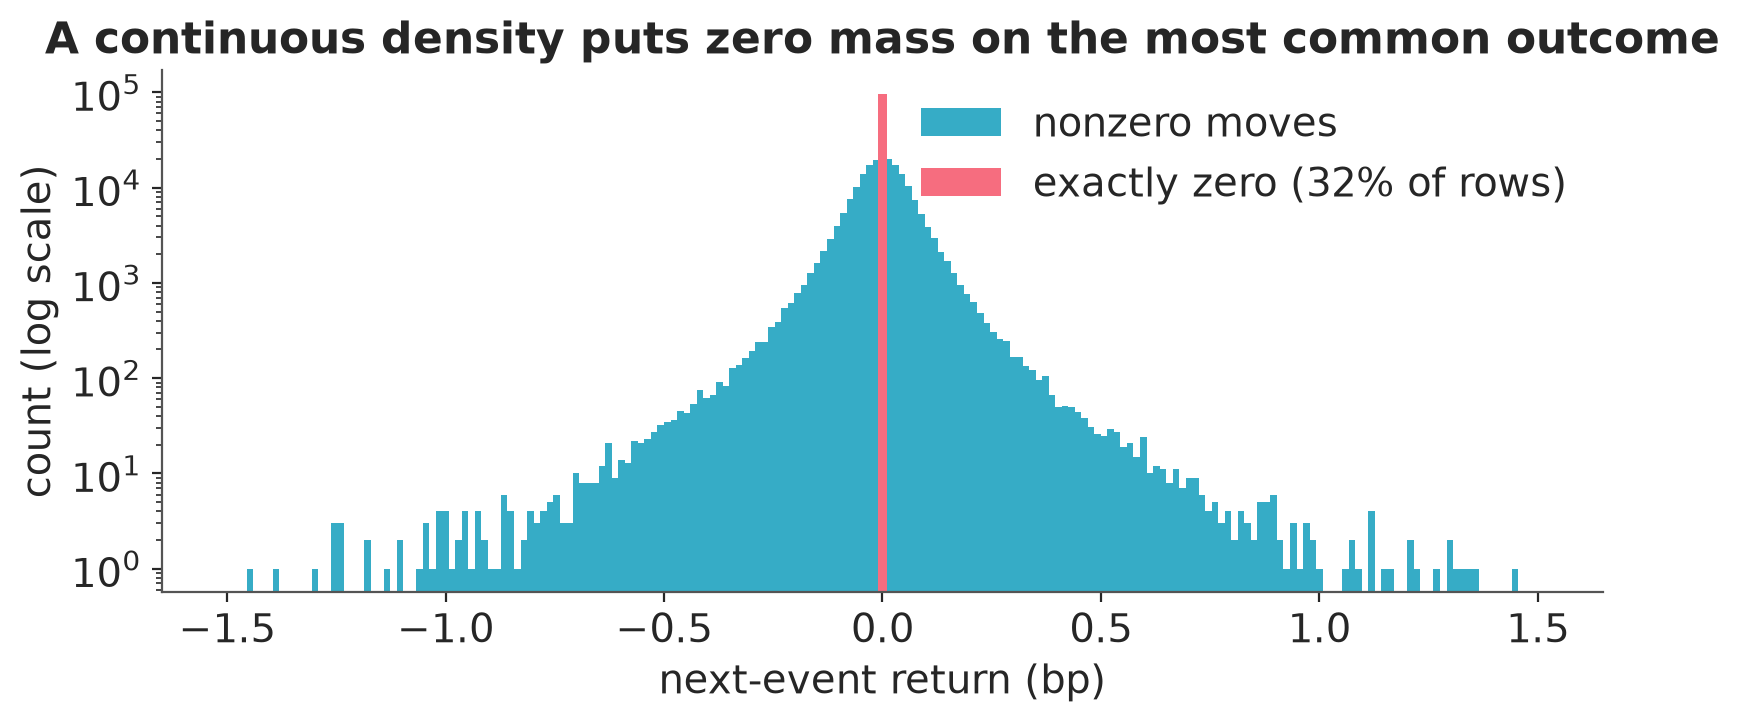

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.5), layout="constrained")
moves = y[m == 1]
ax.hist(moves, bins=201, range=(-1.5, 1.5), log=True, color="C0", label="nonzero moves")
ax.bar(
    [0.0],
    [(m == 0).sum()],
    width=0.02,
    color="C1",
    label=f"exactly zero ({(m == 0).mean():.0%} of rows)",
)
ax.set_xlabel("next-event return (bp)")
ax.set_ylabel("count (log scale)")
ax.set_title("A continuous density puts zero mass on the most common outcome")
ax.legend();

## The on-disk global shuffle

The trap in streaming ordered data is subtle enough to deserve its own
section. A bounded runtime shuffle buffer only *block*-shuffles a strongly
ordered stream: with tick data sorted by symbol and time, early optimization
steps would only ever see early dates and the first symbols, and an early
stopping decision would be biased by construction. The fix is to shuffle
**once, globally, on disk at ETL time**: every row gets a deterministic hash
key, rows are scattered across shards by that key, and each shard is sorted by
it. After that, sequential reads follow one fixed, data-independent
permutation — pseudo-random, because it comes from a hash of the row index
rather than from anything in the row, and replayed identically each epoch,
which is single-shuffle SGD semantics rather than fresh per-step subsampling —
and the loader can run with `shuffle=False`, without a copy through the
shuffle buffer.

In [6]:
data_dir = tempfile.mkdtemp(prefix="ticks_")
table = pa.table(
    {
        "y_bp": y.astype(np.float32),
        "m": m,
        "d": d.astype(np.int8),
        "q_std": q.astype(np.float32),
        "a_std": a.astype(np.float32),
        "ylag_bp": ylag.astype(np.float32),
        "hour": hour.astype(np.int8),
        "sym": sym.astype(np.int16),
    }
)


def splitmix64(x):
    x = (x + np.uint64(0x9E3779B97F4A7C15)) & np.uint64(0xFFFFFFFFFFFFFFFF)
    x = ((x ^ (x >> np.uint64(30))) * np.uint64(0xBF58476D1CE4E5B9)) & np.uint64(0xFFFFFFFFFFFFFFFF)
    x = ((x ^ (x >> np.uint64(27))) * np.uint64(0x94D049BB133111EB)) & np.uint64(0xFFFFFFFFFFFFFFFF)
    return x ^ (x >> np.uint64(31))


key = splitmix64(np.arange(n, dtype=np.uint64))
order = np.argsort(key, kind="stable")
n_shards, BATCH = 10, 1_000
# Row groups are the loader's batches on the shuffle=False path, so the geometry is
# chosen to divide exactly: 10 shards x 30,000 rows, 30 groups of 1,000 each.
assert n % n_shards == 0 and (n // n_shards) % BATCH == 0
for i in range(n_shards):
    part = table.take(order[i::n_shards])
    pq.write_table(part, os.path.join(data_dir, f"shard_{i:03d}.parquet"), row_group_size=BATCH)

# the head of every shard has to mix hours and symbols already; check all of them
for i in range(n_shards):
    head = pq.read_table(os.path.join(data_dir, f"shard_{i:03d}.parquet")).slice(0, 10_000)
    assert len(np.unique(head["hour"])) == 24
    assert len(np.unique(head["sym"])) == n_symbols
print(f"first 10k rows of every shard cover all 24 hours and all {n_symbols} symbols")

first 10k rows of every shard cover all 24 hours and all 12 symbols


The assertion is the one to keep: the head of every shard must already mix
every hour and every symbol, checked rather than assumed.

Be clear about what this cell is and is not. It is the pedagogical miniature:
it builds the whole table, the whole key array and the whole permutation in
memory, which is exactly what one cannot do once the data stops fitting. What
follows it — the inference — is genuinely disk-backed, but the preprocessing
above is not. The out-of-core version of the same permutation is two passes:
hash-scatter rows into shards with bounded row-group appends, then sort each
shard independently, so no step holds more than one shard.

So that the fit really does run against disk rather than against arrays still
resident from the generator, the row-scale objects are released first:

In [7]:
del table, part, head, key, order, y, m, d, q, a, ylag, sym, hour, B, moves
del logit_pi, log_sigma, t_draw, sigma
gc.collect()
print("row-scale generator arrays released; the fit reads from", data_dir)

row-scale generator arrays released; the fit reads from /var/folders/cy/37hb0cnx22lbt9_h8y4wtn2w0000gn/T/ticks_0c_z9zdw


## Streaming the model

With `shuffle=False` the `DataLoader` passes source blocks through verbatim —
one block per Parquet row group, in a frozen column order — which is why the
shards above were written with `row_group_size` equal to the batch size, and
why the row counts were chosen to divide exactly. That is worth doing
deliberately: on this path the loader hands you the row groups it finds, so a
ragged geometry gives ragged batches, `len(loader)` (which is
`total_size // batch_size`) stops matching the number of blocks an epoch
yields, and the recorded loss picks up a deterministic sawtooth that has
nothing to do with convergence (the fitting section explains why the recorded
value scales with the block size). The model reads
one `pm.Data` placeholder; everything derived — the Fourier basis, the
integer symbol index — is computed inside the graph, so advancing the stream
is a single `set_value` per step.

In [8]:
columns = ["y_bp", "m", "d", "q_std", "a_std", "ylag_bp", "hour", "sym"]
loader = DataLoader(
    parquet_source(data_dir, columns=columns),
    batch_size=BATCH,
    shuffle=False,  # the shards are already globally shuffled on disk
    total_size="auto",
)

# Count one epoch rather than inferring it. With a divisible geometry every block
# is the same size, so the count and len(loader) agree — which is what the rest of
# the notebook relies on.
block_rows = [b.shape[0] for b in loader]
steps_per_epoch = len(block_rows)
assert set(block_rows) == {BATCH}
assert sum(block_rows) == loader.total_size == n == steps_per_epoch * BATCH
assert len(loader) == steps_per_epoch
print(
    f"N = {loader.total_size:,} rows -> {steps_per_epoch} blocks of {BATCH} per epoch, "
    f"conserving {sum(block_rows):,} rows; len(loader) = {len(loader)}"
)

N = 300,000 rows -> 300 blocks of 1000 per epoch, conserving 300,000 rows; len(loader) = 300


Two things that assertion pins down. First, **nothing is dropped**: verbatim
pass-through streams every row exactly once per epoch. (Ragged geometry would
still lose nothing — PyMC reads `b` from the batch actually installed, so a
short block is weighted up by its own size — but it would cost the clean
diagnostics below, which is why the shards divide.) Only the shuffle-buffer
path drops a trailing partial batch, and this notebook never uses it.

Second, a precision about Gate 1 that matters for how the fit should be
described. The permutation is fixed once, on disk, and then replayed in the
same order every epoch. Each row is included exactly once per pass, but the
batch at step $t$ is a deterministic function of $t$, not a fresh uniform
draw — so the individual updates are not the conditionally unbiased stochastic
gradients of the $N/B$ identity. This is single-shuffle, cyclic finite-sum
optimization, and it is the arrangement the epoch-scale diagnostics later in
the notebook exploit.

In [9]:
def build_model(symbols, batch_init, total_size):
    coords = {"symbol": list(symbols), "harmonic": ["sin1", "cos1", "sin2", "cos2"]}
    with pm.Model(coords=coords) as model:
        batch = pm.Data("batch", batch_init)
        y_ = batch[:, 0]
        d_ = batch[:, 2]
        q_ = batch[:, 3]
        a_ = batch[:, 4]
        ylag_ = batch[:, 5]
        w = 2.0 * np.pi * batch[:, 6] / 24.0
        B_ = pt.stack([pt.sin(w), pt.cos(w), pt.sin(2 * w), pt.cos(2 * w)], axis=1)
        sym_ = pt.cast(batch[:, 7], "int32")

        kappa0 = pm.Normal("kappa0", 0.0, 5.0)
        c = pm.Normal("c", 0.0, 0.5, dims="harmonic")
        lambda_a = pm.Normal("lambda_a", 0.0, 0.5)
        lambda_q = pm.Normal("lambda_q", 0.0, 0.5)

        alpha0 = pm.Normal("alpha0", 0.0, 5.0)
        g = pm.Normal("g", 0.0, 0.3, dims="harmonic")
        beta_a = pm.Normal("beta_a", 0.0, 0.3)
        beta_q = pm.Normal("beta_q", 0.0, 0.3)

        theta_d = pm.Normal("theta_d", 0.0, 0.25)
        theta_r = pm.Normal("theta_r", 0.0, 0.25)

        tau_k, tau_ph, tau_al, tau_sh, tau_ba = (
            pm.LogNormal(name, 0.0, 1.5)
            for name in ["tau_k", "tau_ph", "tau_al", "tau_sh", "tau_ba"]
        )
        b_k = pm.Normal("b_k", 0.0, tau_k, dims="symbol")
        b_ph = pm.Normal("b_ph", 0.0, tau_ph, dims=("symbol", "harmonic"))
        b_al = pm.Normal("b_al", 0.0, tau_al, dims="symbol")
        b_sh = pm.Normal("b_sh", 0.0, tau_sh, dims=("symbol", "harmonic"))
        b_ba = pm.Normal("b_ba", 0.0, tau_ba, dims="symbol")

        eta = pm.Normal("eta", 5.0, 1.0)
        nu = pm.Deterministic("nu", 1.0 + pt.softplus(eta))

        logit_pi = (
            kappa0
            + b_k[sym_]
            + (B_ * (c + b_ph[sym_])).sum(axis=-1)
            + lambda_a * a_
            + lambda_q * q_
        )
        log_sigma = (
            alpha0
            + b_al[sym_]
            + (B_ * (g + b_sh[sym_])).sum(axis=-1)
            + (beta_a + b_ba[sym_]) * a_
            + beta_q * q_
        )
        mu = theta_d * d_ + theta_r * ylag_

        def hurdle_logp(value, logit_pi, mu, log_sigma, nu):
            # one coherent mixed distribution: an atom at exactly zero plus a
            # Student-t density off zero — the move indicator is value != 0,
            # never a separate parameter, so logp and random describe the SAME law
            sigma = pt.exp(log_sigma)
            t_ll = (
                pt.gammaln((nu + 1.0) / 2.0)
                - pt.gammaln(nu / 2.0)
                - 0.5 * pt.log(nu * np.pi)
                - log_sigma
                - (nu + 1.0) / 2.0 * pt.log1p(((value - mu) / sigma) ** 2 / nu)
            )
            moved = pt.neq(value, 0.0)
            return pt.where(moved, -pt.softplus(-logit_pi) + t_ll, -pt.softplus(logit_pi))

        def hurdle_random(logit_pi, mu, log_sigma, nu, rng=None, size=None):
            # simulate the same law: first whether the price moves, then how far
            pi = 1.0 / (1.0 + np.exp(-logit_pi))
            move = rng.random(size=size) < pi
            draw = mu + np.exp(log_sigma) * rng.standard_t(nu, size=size)
            return np.where(move, draw, 0.0)

        pm.CustomDist(
            "y_obs",
            logit_pi,
            mu,
            log_sigma,
            nu,
            logp=hurdle_logp,
            random=hurdle_random,
            observed=y_,
            total_size=total_size,
        )
    return model

Two implementation notes worth pausing on. The likelihood is a
{class}`~pymc.CustomDist` with a `logp`, not a `pm.Potential`: `CustomDist`
gives the term *observed-RV semantics*, which is what makes PyMC's own
`total_size` minibatch rescaling apply. And
the hurdle's two logs are written with `softplus` —
$\log \pi = -\operatorname{softplus}(-x)$,
$\log(1-\pi) = -\operatorname{softplus}(x)$ — which is exact and stable at both
tails. The exact float comparison `value != 0` is safe here because the zeros are
*structural*: the generator writes an exact 0.0 when the hurdle says the price
did not move, and every nonzero draw is many orders of magnitude above the
float32 subnormal range. On real data the same comparison is safe as long as
returns are computed so that "no move" produces an exact zero rather than a
rounding artefact — worth checking once, in the feature code.

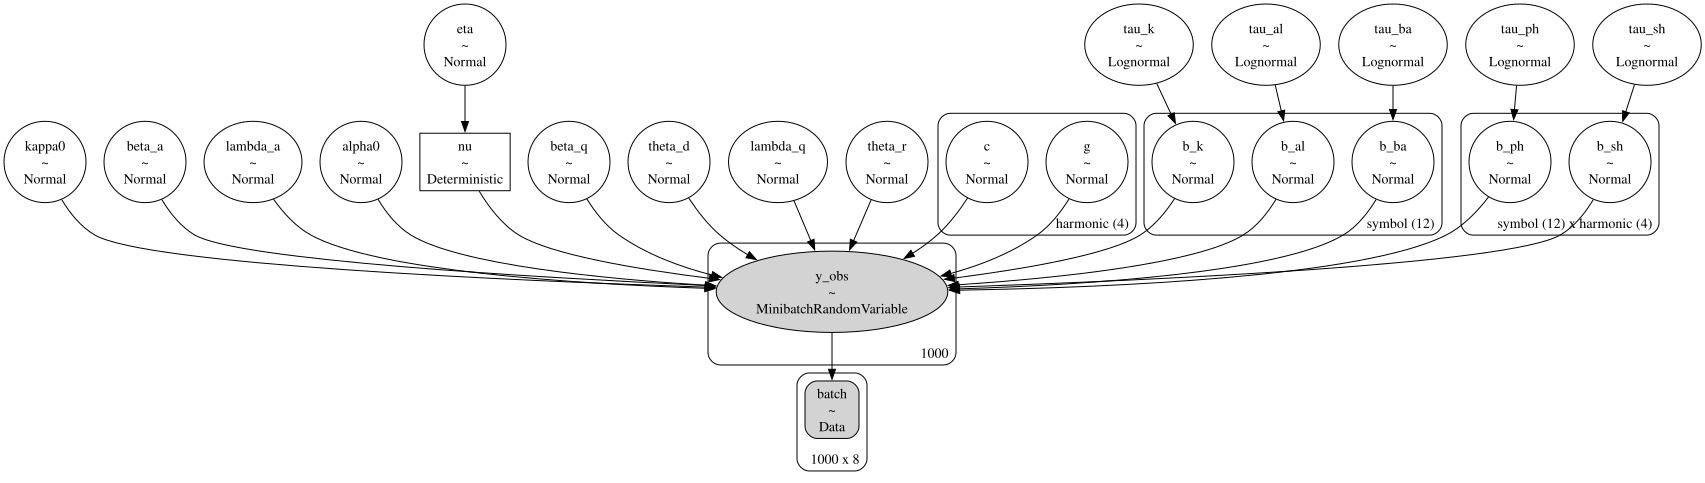

In [10]:
model = build_model(
    [f"SYM{i:02d}" for i in range(n_symbols)], next(iter(loader)), loader.total_size
)
pm.model_to_graphviz(model)

The plate diagram is an inventory rather than a picture of the two links: five
partially pooled effect families on the symbol plate, one shared tail
parameter, and a single observed node whose batch dimension is whatever the
placeholder currently holds. The two linear predictors live inside the
likelihood's `logp` and are not separate nodes; the equations above are where
that structure is visible.

The loop below is the whole streaming adapter: a `pm.fit` callback that pushes
the next block into the placeholder after each step. pymc-extras#710 proposes
an interim wrapper around this same data-advance lifecycle while
pymc-extras#635 develops the longer-term ADVI API, so the twenty lines here are
deliberately the minimal version a notebook can own.

In [11]:
class StreamAdvance:
    """pm.fit callback: put the next minibatch into the placeholder after each step."""

    def __init__(self, model, loader):
        self._shared = model["batch"]
        self._stream = self._endless(loader)

    @staticmethod
    def _endless(loader):
        while True:
            yield from loader

    def prime(self):
        self._shared.set_value(next(self._stream), borrow=True)

    def __call__(self, approx, losses, i):
        self._shared.set_value(next(self._stream), borrow=True)


class ParamTrace:
    """pm.fit callback: record the variational parameters after every step."""

    def __init__(self):
        self.mu, self.rho = [], []

    def __call__(self, approx, losses, i):
        mu, rho = approx.params
        self.mu.append(mu.get_value())
        self.rho.append(rho.get_value())


stream = StreamAdvance(model, loader)
stream.prime()
tail = ParamTrace()

with model:
    advi = pm.ADVI(random_seed=RANDOM_SEED)
advi.fit(6_000, obj_optimizer=pm.adam(learning_rate=0.02), callbacks=[stream], progressbar=False)
approx = advi.fit(
    2_400,
    obj_optimizer=pm.adam(learning_rate=0.005),
    callbacks=[stream, tail],
    progressbar=False,
)

The fit is mean-field ADVI {cite:p}`kucukelbir2015automatic` driven by Adam.
The two-stage learning rate is deliberate. A constant step size that is
comfortable early is too large near the optimum, where it keeps the
variational mean bouncing instead of settling; dropping it once the descent
has flattened is the cheapest fix. The loss curve below is the evidence
available here — the visible band narrows after the change.

Before plotting it, one property of `approx.hist` that is easy to get wrong and
that changes what the numbers mean. PyMC normalizes the minibatch objective
**twice**: the observed log-probability is scaled up by $N/b$ so the gradient
targets the full-data model, and then the variational objective is divided by
that same constant, because `scale_cost_to_minibatch` is on by default. What
gets recorded per step is therefore

$$
F_t = -\sum_{i \in B_t} \mathbb{E}_q\left[\log p(y_i \mid \theta)\right]
      + \frac{b}{N}\,\mathrm{KL}(q \Vert p),
$$

which lives on the scale of *one batch*, not of the full dataset — and which
would move mechanically with $b$ if the blocks were ragged. Multiplying by
$N/b$ puts it back on the full-data negative-ELBO scale, and with equal blocks
that is one constant:

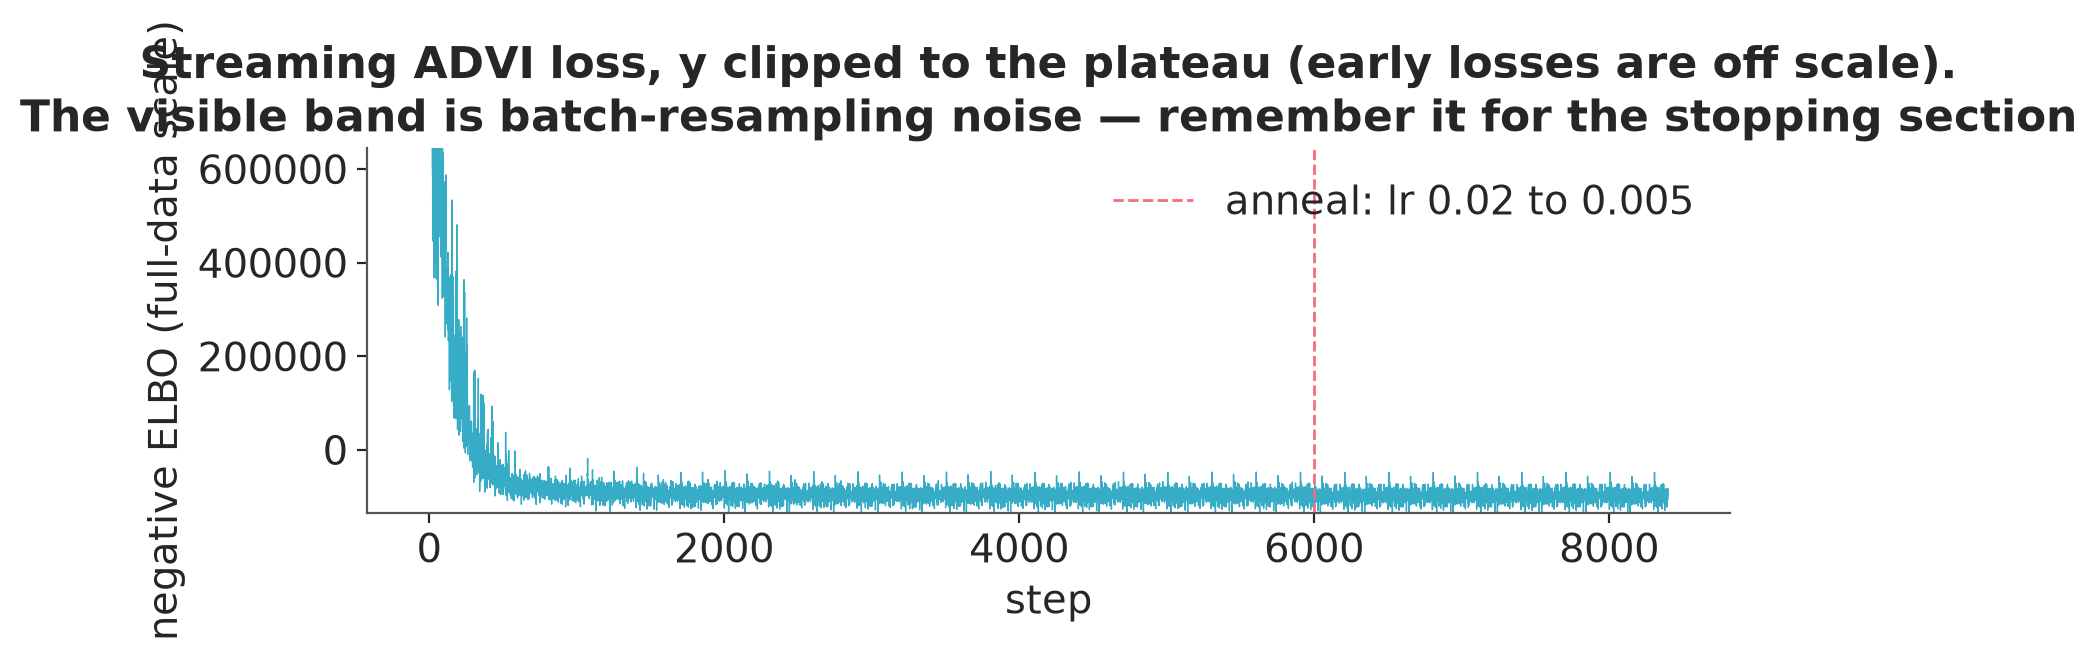

In [12]:
ELBO_SCALE = loader.total_size / BATCH  # undo PyMC's scale_cost_to_minibatch
loss = np.asarray(approx.hist, dtype=float) * ELBO_SCALE

fig, ax = plt.subplots(figsize=(8, 3), layout="constrained")
ax.plot(loss, lw=0.5)
ax.axvline(6_000, color="C1", ls="--", lw=1, label="anneal: lr 0.02 to 0.005")
ax.set_ylim(np.quantile(loss, 0.002), np.quantile(loss, 0.995))
ax.set_xlabel("step")
ax.set_ylabel("negative ELBO (full-data scale)")
ax.set_title(
    "Streaming ADVI loss, y clipped to the plateau (early losses are "
    "off scale).\nThe visible band is batch-resampling noise — "
    "remember it for the stopping section"
)
ax.legend();

## The last iterate is not the answer

Before reading a single parameter off this fit, one property of the replay has
to be dealt with. The batch at step $t$ is a deterministic function of $t$ with
period one epoch, so the gradient sequence is periodic and the optimizer's
iterate inherits a periodic component. Two measurements separate that component
from genuine progress: compare the same phase in consecutive epochs, and look at
the spread within a single epoch.

In [13]:
mu_t = np.asarray(tail.mu)
sd_unc = approx.std.eval()  # variational sd in the unconstrained space, before averaging
ends = mu_t[steps_per_epoch - 1 :: steps_per_epoch]  # same phase, one epoch apart
drift = np.abs(ends[-1] - ends[-2]) / sd_unc
last = mu_t[-steps_per_epoch:]
swing = (last.max(0) - last.min(0)) / sd_unc
print(
    f"epoch over epoch, same phase: median {np.median(drift):.2f}, max {drift.max():.2f} sd\n"
    f"within the last epoch:        median {np.median(swing):.2f}, max {swing.max():.1f} sd"
)

epoch over epoch, same phase: median 0.11, max 0.58 sd
within the last epoch:        median 4.31, max 41.2 sd


Read those two lines together. Between the same points of consecutive epochs the
mean barely moves, so the systematic descent really has flattened — the fit is
not being stopped in mid-descent. Within one epoch it swings by multiples of its
own posterior width. The optimizer is not converging to a point; it is orbiting
one, on a cycle locked to the order the rows are replayed in, and the last
iterate is whatever phase of that orbit the step budget happened to end on.

That is not a subtlety to note and move past. It means the number you would
report depends on where you stop, so the fit is summarized by averaging the
variational parameters over the final whole pass — a full period of the cycle,
which is what makes the average cancel it. This is Polyak–Ruppert averaging, and
it is why the step budget above is a whole number of epochs. The same tail
average is what [pymc-extras#722](https://github.com/pymc-devs/pymc-extras/pull/722)
applies to its own iterates for the same reason.

In [14]:
rho_t = np.asarray(tail.rho)
approx.params[0].set_value(mu_t[-steps_per_epoch:].mean(0))
approx.params[1].set_value(rho_t[-steps_per_epoch:].mean(0))
print(f"variational parameters averaged over the final {steps_per_epoch} steps (one epoch)")

variational parameters averaged over the final 300 steps (one epoch)


Everything below reads from that averaged approximation.

## Did it recover the truth?

In [15]:
idata = approx.sample(2_000, random_seed=RANDOM_SEED)
post = idata.posterior

scalar_params = [
    "kappa0",
    "alpha0",
    "lambda_a",
    "lambda_q",
    "beta_a",
    "beta_q",
    "theta_d",
    "theta_r",
    "nu",
]
rows = {name: [float(post[name].mean()), float(post[name].std())] for name in scalar_params}
# the intercepts share a ridge with their group means; only the sums are identified
for icpt, b in [("kappa0", "b_k"), ("alpha0", "b_al"), ("beta_a", "b_ba")]:
    s = post[icpt] + post[b].mean("symbol")
    rows[f"{icpt} + mean({b})"] = [float(s.mean()), float(s.std())]
recovery = pd.DataFrame(rows, index=["mean", "sd"]).T
recovery["truth"] = [truth[p] for p in scalar_params] + [
    truth["kappa0"],
    truth["alpha0"],
    truth["beta_a"],
]
recovery["abs_error"] = (recovery["mean"] - recovery["truth"]).abs()
recovery["z"] = (recovery["mean"] - recovery["truth"]) / recovery["sd"]
recovery.round(4)

,mean,sd,truth,abs_error,z
kappa0,0.5336,0.0048,0.8473,0.3137,-65.2181
alpha0,-1.7012,0.0034,-2.9957,1.2946,378.5027
lambda_a,0.3517,0.0053,0.3500,0.0017,0.3298
lambda_q,0.2065,0.0056,0.2000,0.0065,1.1587
beta_a,0.1624,0.0036,0.1800,0.0176,-4.8789
beta_q,0.1223,0.0031,0.1200,0.0023,0.7391
theta_d,0.0200,0.0002,0.0200,0.0000,-0.0473
theta_r,0.2500,0.0019,0.2500,0.0000,0.0151
nu,3.5097,0.0230,3.5000,0.0097,0.4224
kappa0 + mean(b_k),0.8495,0.0096,0.8473,0.0022,0.2253


The table is a selection — the scalar globals and the three identified sums —
and the figure after it checks one of the five symbol-effect families; that,
plus the two curves for one symbol further down, is the extent of the recovery
evidence here. Read the table bottom-up. The raw intercepts look off by 0.3 and 1.3 — but a
global coefficient and the mean of its group effects are only *jointly*
identified: the likelihood constrains their sum, and the prior only weakly
splits it. The identified sums in the last three rows land within a couple of hundredths
of the truth, the same range as the other likelihood-identified rows.
The same translation ridge exists for every global-coefficient/group-effect
pair in this model (including the vector pairs $c$/$b^{(\pi h)}$ and
$g$/$b^{(\sigma h)}$, whose sums we spare you) — so raw split rows like
`kappa0`, `alpha0`, and `beta_a` are prior-dependent decompositions, not
estimates of their generating values; a sum-to-zero constraint on the symbol
effects is the standard reparameterization when the split itself matters.
The last column standardizes the error by the posterior width, and it has to be
read against identification rather than straight across the table. On the three
raw split rows it is not a recovery statistic at all: `alpha0` reads 379 because
a prior-dependent decomposition can have an arbitrary location and still a
narrow width, which says something about the split and nothing about the fit
(`beta_a`, at $-4.9$, is the same story in miniature). Everything that *is*
identified — the three sums and the six standalone rows — lands inside $1.2$
posterior standard deviations of its generating value, and four of those nine
are inside $0.5$. Without the tail average the same table showed misses of
three to seven; that difference was the orbit, not the estimate.

Two things this table does not license. It does not say the widths are
trustworthy: they are the widths of a mean-field approximation, which has no
correlations to spend, and z-scores this small on one dataset are consistent
with widths that are somewhat too narrow, somewhat too wide, or right — sizing
that needs many simulated datasets, and this notebook fits one. Nor does it
transfer to the raw splits: no amount of data fixes a ridge, only a
reparameterization does.

The stance behind stopping there is a risk-management one, and it is worth
stating plainly: material disagreement between independent-seed fits would be
enough to withhold a claim about a width, while agreement only removes the
instability warning — it does not validate calibration. Replication can veto a
width; it can never certify one.

The more interesting check is hierarchical: what happened to the per-symbol
effects of the two symbols with 1,800 and 900 rows?

posterior sd of the contrast, widest first: S11 0.044 (900 rows), S10 0.023 (1,800 rows), S09 0.019 (4,600 rows) ... narrowest S00 0.007 (90,700 rows)


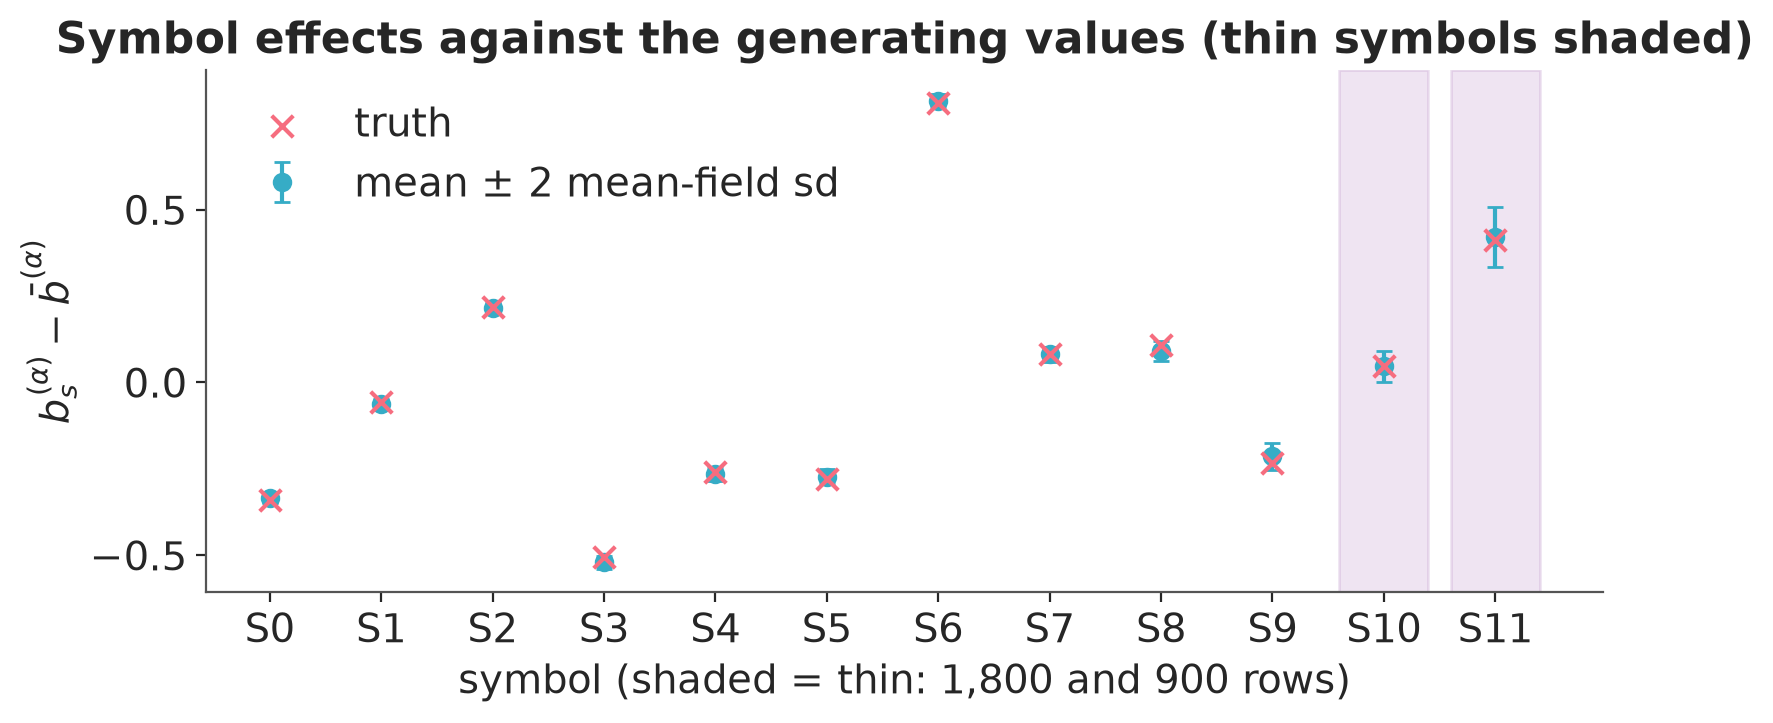

In [16]:
# plot the identified CONTRAST b - mean(b): the table above showed the absolute
# level belongs to a ridge with the intercept, so comparing raw b to raw truth
# would only display the arbitrary level split. Hand-rolled rather than
# az.plot_forest because the display is bespoke: truth overlay + thin shading.
bc = post["b_al"] - post["b_al"].mean("symbol")
b_mean = bc.mean(("chain", "draw")).values
b_sd = bc.std(("chain", "draw")).values
b_truth = 0.35 * z_truth["z_al"]  # the generator's scale times its z draws
b_truth = b_truth - b_truth.mean()

fig, ax = plt.subplots(figsize=(8, 3.5), layout="constrained")
x = np.arange(n_symbols)
ax.errorbar(
    x, b_mean, yerr=2 * b_sd, fmt="o", color="C0", capsize=3, label="mean ± 2 mean-field sd"
)
ax.scatter(x, b_truth, marker="x", color="C1", s=60, zorder=3, label="truth")
for t in thin:
    ax.axvspan(t - 0.4, t + 0.4, color="C3", alpha=0.12)
ax.set_xticks(x)
ax.set_xticklabels([f"S{i}" for i in x])
ax.set_xlabel("symbol (shaded = thin: 1,800 and 900 rows)")
ax.set_ylabel(r"$b^{(\alpha)}_s - \bar{b}^{(\alpha)}$")
ax.set_title("Symbol effects against the generating values (thin symbols shaded)")
ax.legend()

order = np.argsort(-b_sd)
print(
    "posterior sd of the contrast, widest first: "
    + ", ".join(f"S{i:02d} {b_sd[i]:.3f} ({counts[i]:,} rows)" for i in order[:3])
    + f" ... narrowest S{order[-1]:02d} {b_sd[order[-1]]:.3f} ({counts[order[-1]]:,} rows)"
)

What the figure supports is narrower than the usual slogan, so it is worth
being exact. The posterior spread is widest for the symbols with the least
data — the printout orders them — which is the hierarchy expressing that it
knows less about those groups {cite:p}`gelman2006data`. The point estimates
track their generating values across the board, including the thin ones.

What the figure does *not* show is shrinkage in the strict sense: that would
need an unpooled per-symbol fit to compare against, and this notebook does not
run one. Nor are the bars calibrated intervals — the paragraph above declined
to treat mean-field widths that way, and that applies to their ordering too.
And whether pooling improves held-out prediction on real data is a separate
question again, which nothing here tests.

What do those parameters mean as *objects*? For one symbol, holding the
covariates at $a = q = 0$, the fit implies two curves over the event clock: the
probability that the next event leaves the price unchanged, and the 90%
half-width of the move given that one happens. Both are built from
global-plus-symbol sums, so neither sits on the translation ridge.

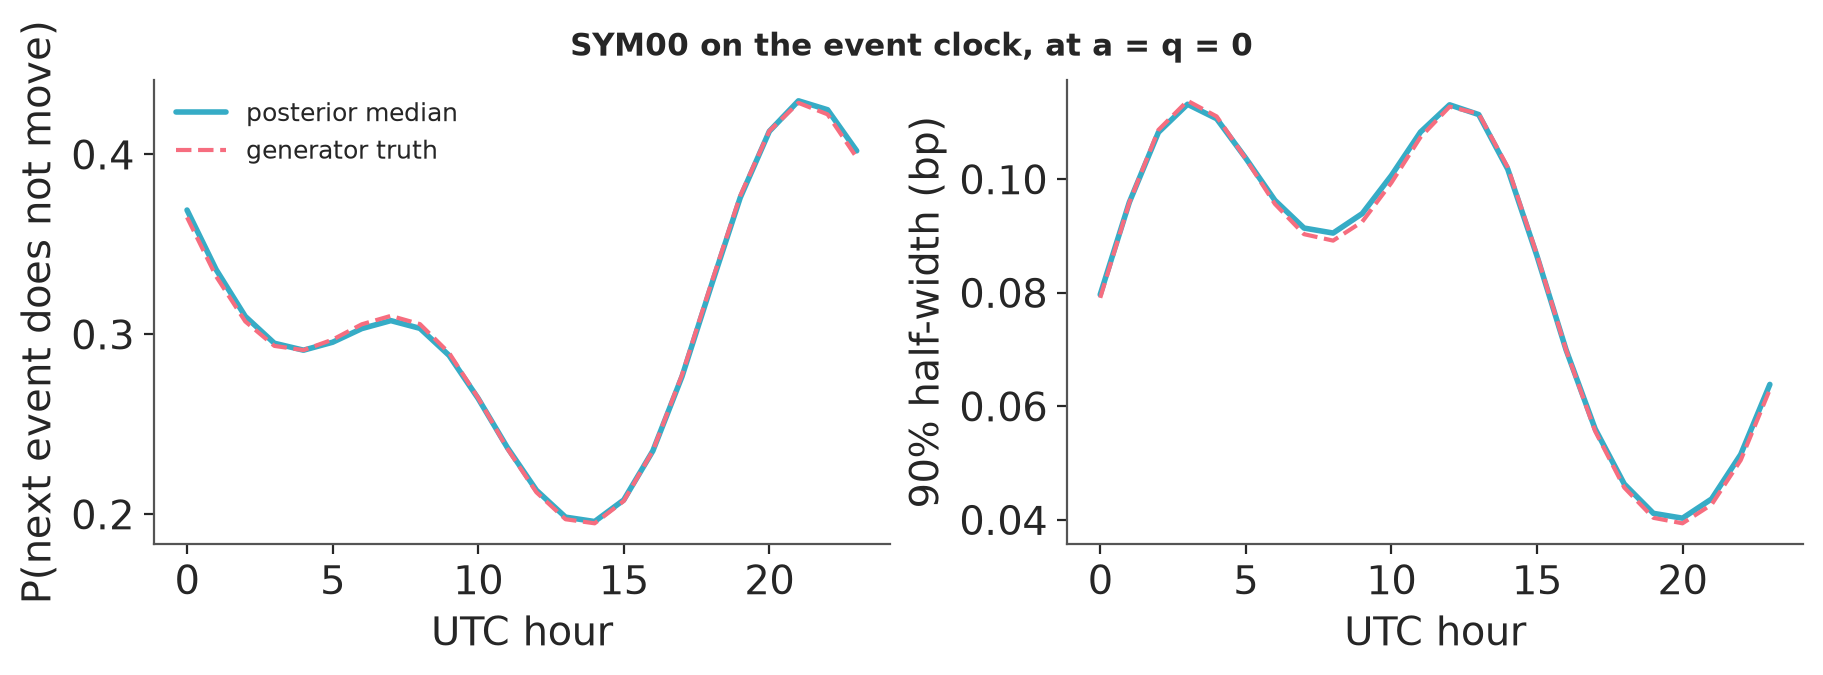

In [17]:
s_idx, hours = 0, np.arange(24)
Bh = hour_basis(hours)  # (24, 4)
# .dataset: idata.posterior is a DataTree in arviz 1.x
st = post.dataset.stack(sample=("chain", "draw"))


def pick(name, *dims):
    return st[name].transpose(*dims, "sample").values


logit_pi = (
    pick("kappa0")[None, :]
    + pick("b_k", "symbol")[s_idx][None, :]
    + Bh @ (pick("c", "harmonic") + pick("b_ph", "symbol", "harmonic")[s_idx])
)
log_sigma = (
    pick("alpha0")[None, :]
    + pick("b_al", "symbol")[s_idx][None, :]
    + Bh @ (pick("g", "harmonic") + pick("b_sh", "symbol", "harmonic")[s_idx])
)
# transform each draw, then summarise: the median of a function, not a function of medians
zero_prob = np.median(1.0 / (1.0 + np.exp(logit_pi)), axis=1)
half90 = np.median(np.exp(log_sigma) * stats.t.ppf(0.95, pick("nu"))[None, :], axis=1)

t_logit = (
    truth["kappa0"]
    + 0.30 * z_truth["z_k"][s_idx]
    + Bh @ (truth["c"] + 0.15 * z_truth["z_ph"][s_idx])
)
t_logsig = (
    truth["alpha0"]
    + 0.35 * z_truth["z_al"][s_idx]
    + Bh @ (truth["g"] + 0.12 * z_truth["z_sh"][s_idx])
)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), layout="constrained")
for ax, post_curve, truth_curve, ylab in [
    (axes[0], zero_prob, 1.0 / (1.0 + np.exp(t_logit)), "P(next event does not move)"),
    (axes[1], half90, np.exp(t_logsig) * stats.t.ppf(0.95, truth["nu"]), "90% half-width (bp)"),
]:
    ax.plot(hours, post_curve, color="C0", lw=2, label="posterior median")
    ax.plot(hours, truth_curve, color="C1", ls="--", lw=1.5, label="generator truth")
    ax.set_xlabel("UTC hour")
    ax.set_ylabel(ylab)
axes[0].legend(fontsize=9)
fig.suptitle(f"SYM{s_idx:02d} on the event clock, at a = q = 0", fontsize=11);

The half-width is a quantile of the *outcome* distribution, not a credible band
for the curve: it answers "how far does a move go", and it stays finite for any
$\nu > 0$, which is why the notebook reports it instead of a conditional
standard deviation — the Student-t variance exists only for $\nu > 2$, and
nothing in this model guarantees that. Under this generator, the fit recovers
both shapes; on real data the same two curves would be estimates, and would
need out-of-sample evaluation before being used for anything.

## In-sample posterior predictive adequacy

A recovery table checks parameters; a posterior predictive check asks the
model to reproduce the data features it exists to describe. The `CustomDist`
carries a `random` implementation alongside its `logp`, so
{func}`~pymc.sample_posterior_predictive` works out of the box. The two
features that matter for this model are the exact-zero share and the heavy
conditional tail:

In [18]:
eval_batch = next(iter(loader))
model["batch"].set_value(eval_batch, borrow=True)  # same path the callback uses
with model:
    idata = pm.sample_posterior_predictive(
        idata,
        var_names=["y_obs"],
        random_seed=RANDOM_SEED,
        extend_inferencedata=True,
        progressbar=False,
    )

pp = idata.posterior_predictive["y_obs"].stack(sample=("chain", "draw")).values.T
y_eval = eval_batch[:, 0]

zero_share = (pp == 0).mean(axis=1)
med_nonzero = np.array([np.median(np.abs(d[d != 0])) for d in pp[:500]])
q99_nonzero = np.array([np.quantile(np.abs(d[d != 0]), 0.99) for d in pp[:500]])


def check_row(observed, draws):
    lo, hi = np.quantile(draws, [0.05, 0.95])
    return [observed, draws.mean(), lo, hi]


y_nonzero = np.abs(y_eval[y_eval != 0])
pd.DataFrame(
    [
        check_row((y_eval == 0).mean(), zero_share),
        check_row(np.median(y_nonzero), med_nonzero),
        check_row(np.quantile(y_nonzero, 0.99), q99_nonzero),
    ],
    columns=["observed", "pp mean", "pp 5%", "pp 95%"],
    index=["zero share", "median |move| (bp)", "q99 |move| (bp)"],
).round(3)

,observed,pp mean,pp 5%,pp 95%
zero share,0.300,0.322,0.299,0.346
median |move| (bp),0.039,0.040,0.037,0.043
q99 |move| (bp),0.298,0.331,0.268,0.410


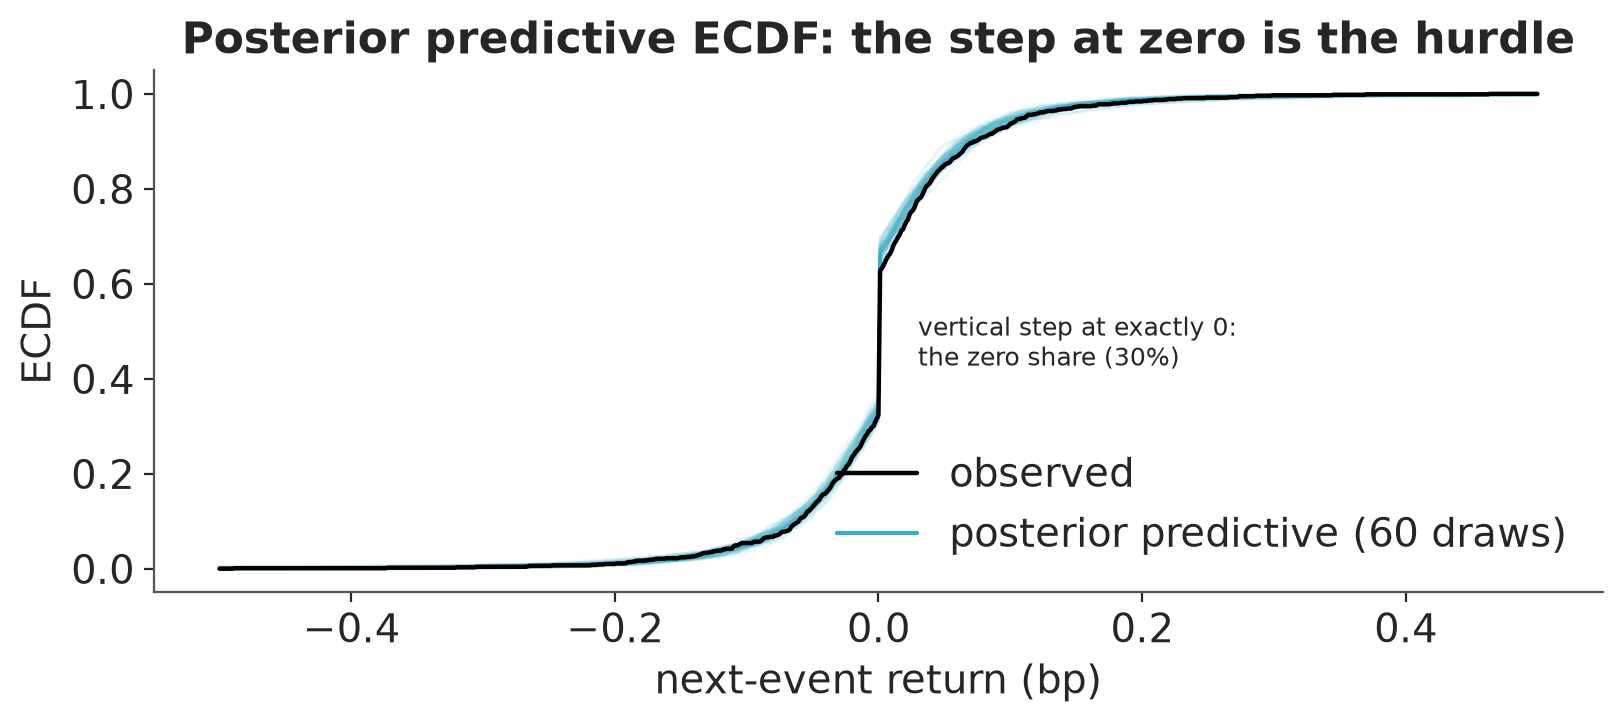

In [19]:
# hand-rolled ECDF: the bespoke feature is the annotated discrete jump at zero,
# which the predictive must reproduce in both location and height
fig, ax = plt.subplots(figsize=(8, 3.5), layout="constrained")
grid = np.linspace(-0.5, 0.5, 801)
for draw in pp[:60]:
    ax.plot(grid, np.searchsorted(np.sort(draw), grid) / draw.size, color="C0", alpha=0.08, lw=1)
ax.plot(
    grid, np.searchsorted(np.sort(y_eval), grid) / y_eval.size, color="k", lw=1.6, label="observed"
)
ax.plot([], [], color="C0", label="posterior predictive (60 draws)")
zero_jump = (y_eval == 0).mean()
below = (y_eval < 0).mean()
ax.annotate(
    f"vertical step at exactly 0:\nthe zero share ({zero_jump:.0%})",
    (0.03, below + zero_jump / 2),
    fontsize=9,
    ha="left",
    va="center",
)
ax.set_xlabel("next-event return (bp)")
ax.set_ylabel("ECDF")
ax.set_title("Posterior predictive ECDF: the step at zero is the hurdle")
ax.legend(loc="lower right");

All three statistics sit inside their predictive 90% bands, though the zero
share sits close to the lower edge — 0.300 observed against a band starting at
0.299 — so it is a pass with almost no margin rather than a comfortable one.
Two limits on what
that establishes. The heading is literal — the evaluation batch was seen during
the fit, so this is adequacy, not generalisation, and a held-out split is the
next thing to add before any of this is used to compare models. And the check
is one batch, one step ahead, with the observed `ylag` held fixed: it does not
simulate a price path forward, and it says nothing about the hierarchy, the
hourly curves, or the covariate responses, each of which would need its own
stratified check.

## What a stopping rule has to be able to see

A streamed ELBO trace is noisy: every value is a one-batch, one-Monte-Carlo
estimate, so consecutive losses differ mostly because the batch changed. That
makes "has it converged?" a signal-detection problem, and the horizon over
which you look is the whole game.

Write the standardised *block contrast* at horizon $w$: average the $w$ losses
before a point, average the $w$ losses after it, and divide the difference by
the noise scale of that difference,

$$
z_w(t) = \frac{\bar L_{t-2w:t-w} - \bar L_{t-w:t}}
              {\hat\sigma \sqrt{2/w}},
$$

with $\hat\sigma$ estimated from successive differences. Positive $z_w$ means
the loss fell. For noise without long memory, averaging divides it by
$\sqrt{w}$ while a steady drift accumulates linearly in $w$, so the detectable
drift shrinks like $w^{-3/2}$: the horizon does not merely smooth the picture,
it sets what is visible at all. A fixed replay order is not noise of that kind,
and the printout below shows where the generic scaling breaks — in the
notebook's favour.

In [20]:
# Stage 2 only, on the full-data scale: after the last planned optimizer change,
# which is where a stopping decision would actually be taken.
stage2 = loss[6_000:]
sigma_hat = np.mean(np.abs(np.diff(stage2))) * np.sqrt(np.pi) / 2.0


def signed_z(losses, w):
    """Standardised contrast between adjacent blocks of w losses."""
    csum = np.concatenate([[0.0], np.cumsum(losses)])
    t = np.arange(2 * w, len(losses))
    older = (csum[t - w] - csum[t - 2 * w]) / w
    newer = (csum[t] - csum[t - w]) / w
    return t, (older - newer) / (sigma_hat * np.sqrt(2.0 / w))


horizons = [(1, "per step"), (steps_per_epoch, "one epoch"), (2 * steps_per_epoch, "two epochs")]
# control: a horizon that is NOT a whole number of passes, to test whether the
# variance collapse below is really about epoch alignment
control = [(steps_per_epoch + steps_per_epoch // 2, "1.5 epochs")]
spreads = {}
for w, label in horizons + control:
    _, z = signed_z(stage2, w)
    spreads[label] = z.std()
    print(
        f"{label:>10s} (w={w:4d}):  mean z {z.mean():+.3f}   sd {z.std():.2f}"
        f"   |mean|/sd {abs(z.mean()) / z.std():.2f}"
    )
aligned = max(spreads["one epoch"], spreads["two epochs"])
print(f"\ncontrol spread is {spreads['1.5 epochs'] / aligned:.0f}x the widest aligned spread")

  per step (w=   1):  mean z -0.001   sd 0.99   |mean|/sd 0.00
 one epoch (w= 300):  mean z +0.014   sd 0.03   |mean|/sd 0.56
two epochs (w= 600):  mean z +0.034   sd 0.02   |mean|/sd 2.06
1.5 epochs (w= 450):  mean z +0.021   sd 0.45   |mean|/sd 0.05

control spread is 18x the widest aligned spread


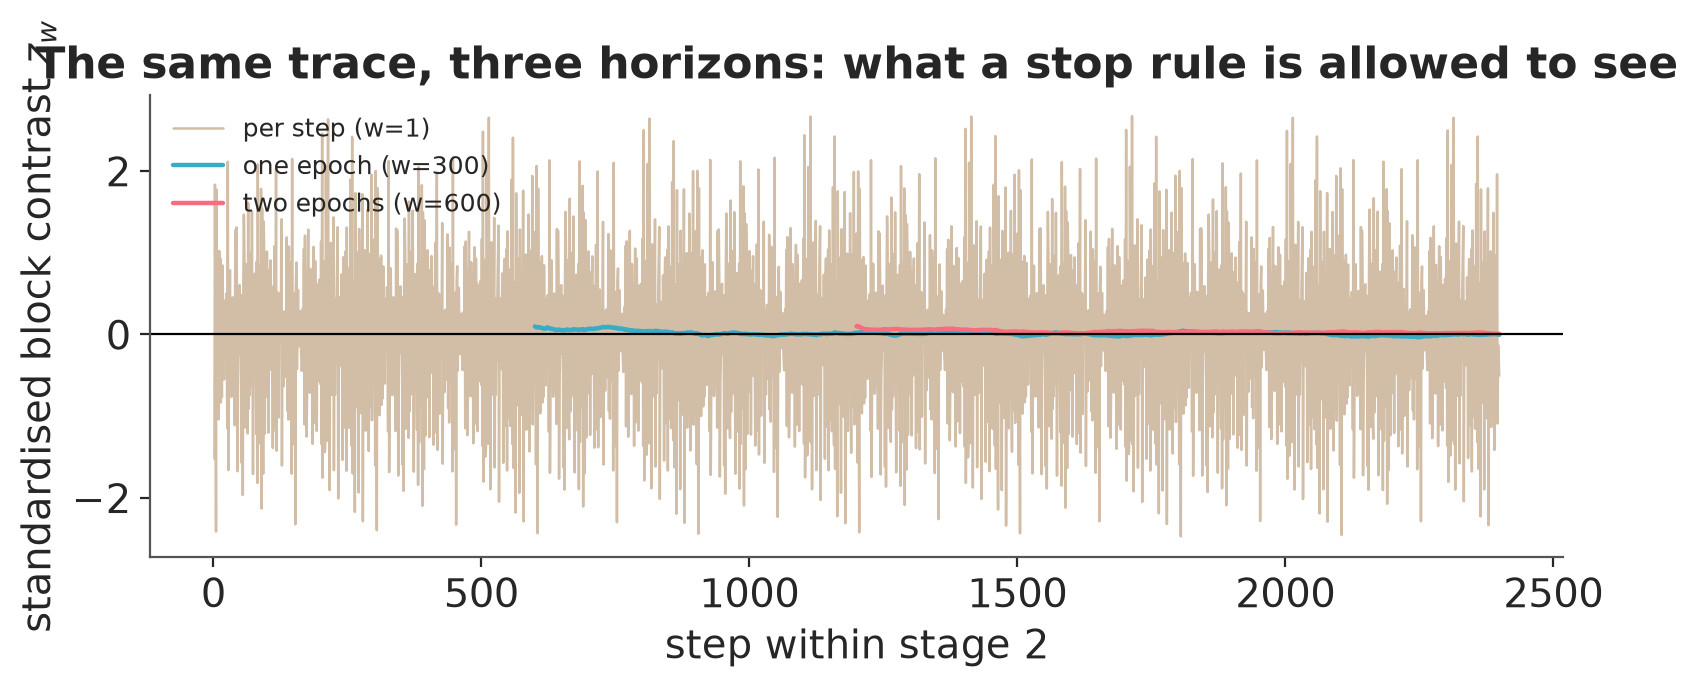

In [21]:
fig, ax = plt.subplots(figsize=(8, 3.2), layout="constrained")
for (w, label), color in zip(horizons, ["C7", "C0", "C1"]):
    t, z = signed_z(stage2, w)
    ax.plot(
        t,
        z,
        color=color,
        lw=0.9 if w == 1 else 1.6,
        alpha=0.5 if w == 1 else 1.0,
        label=f"{label} (w={w})",
    )
ax.axhline(0.0, color="k", lw=0.8)
ax.set_xlabel("step within stage 2")
ax.set_ylabel(r"standardised block contrast $z_w$")
ax.set_title("The same trace, three horizons: what a stop rule is allowed to see")
ax.legend(fontsize=9);

Read the printout as three signal-to-noise ratios. At $w = 1$ the standardised
contrast has unit spread — which is what the $\sqrt{2/w}$ scaling is built to
produce — and a mean indistinguishable from zero: a single increment says
nothing about the trend.

At the two epoch-aligned horizons the spread collapses far below what
independent noise would predict — and the control row explains why. The
shuffle is done once on disk and replayed in the same order every epoch, so a
window of exactly one or two passes averages over the *same rows* every time
and the batch-composition noise, which dominates the per-step view, cancels.
Widen the window to one and a half passes and it does not: the printed ratio
puts the control an order of magnitude above the wider of its two neighbours,
even though it is itself *wider* than the one-epoch window. Nothing but the
alignment changed.

What survives the cancellation is Monte-Carlo noise and the parameter drift
itself, and against that much smaller yardstick the drift becomes visible —
the ratio in the last column rises with the horizon. Two lessons sit on top of
each other here. The horizon is not a smoothing preference, it decides whether
there is anything to see at all; and with a fixed replay order the useful
horizons are the ones commensurate with an epoch, which is a property of how
the data was shuffled, not of the optimizer.

:::{admonition} Why a naive rule does not merely stay silent — it fires
:class: warning
It is tempting to accumulate per-step evidence with a one-sided cumulative-sum
statistic {cite:p}`page1954continuous`, $S \leftarrow \max(0,\ S + (\kappa -
\max(z, 0)))$, stopping when $S$ exceeds a threshold. Read carefully, that
recursion behaves sensibly while there is signal: if the standardised
improvement stays above $\kappa$, the increment is negative and $S$ sits at
zero. The difficulty is what happens when there is *no* resolvable signal.
Under symmetric noise $\mathbb{E}[\max(z,0)]$ is only a fraction of a standard
deviation, so with $\kappa$ above that value $S$ climbs at a roughly constant
rate and crosses any fixed threshold after a roughly fixed number of steps. The
rule therefore cannot tell "converged" from "still improving, but too slowly
for this horizon to see" — it announces the same thing at the same pace in
both cases. Which is why the fix is not a better threshold but a wider horizon,
plus a second yardstick asking whether the remaining improvement is negligible
relative to the reduction already achieved. That design is under review as
[pymc-extras#733](https://github.com/pymc-devs/pymc-extras/pull/733); this
notebook shows the observation problem it exists to solve rather than shipping
a second copy of it.
:::

How much would an online rule be worth here? The retrospective answer is a
benchmark you can only compute afterwards — which is exactly why the online
version is needed:

In [22]:
# t99: the first step at which a trailing average of width one epoch has covered
# 99% of stage 2's total smoothed reduction. Retrospective by construction.
kernel = np.ones(steps_per_epoch) / steps_per_epoch
smoothed = np.convolve(stage2, kernel, mode="valid")
total_drop = smoothed[0] - smoothed.min()
# "valid" convolution starts at the first full window, so index j of `smoothed`
# is the trailing average ending at stage-2 step j + steps_per_epoch, counting
# steps from 1.
t99 = int(np.argmax(smoothed <= smoothed.min() + 0.01 * total_drop)) + steps_per_epoch
print(
    f"stage 2 smoothed reduction: {total_drop:,.2f} nats; "
    f"99% of it reached by step {t99:,} of {len(stage2):,} "
    f"({t99 / len(stage2):.0%} of the stage-2 budget)"
)

stage 2 smoothed reduction: 188.11 nats; 99% of it reached by step 1,947 of 2,400 (81% of the stage-2 budget)


Two honest qualifications about any stop, this one included. What such a rule
detects is a *loss plateau* — a necessary signal, not a proof that the
posterior has converged; the recovery and predictive checks above are the kind
of independent evidence a stop should be paired with. And a plateau in a noisy
loss can only ever be established relative to a horizon: at any finite step, an
improvement small enough is indistinguishable from none.

## Where the pieces live

The streaming stack this notebook exercises is being contributed to
pymc-extras. The map is by role; each pull request's current state is on
GitHub rather than frozen into this page.

| Component | Role | Form in this notebook |
| --- | --- | --- |
| [`DataLoader` / `parquet_source`](https://github.com/pymc-devs/pymc-extras/pull/698) | Turns an out-of-core source into minibatches and owns `total_size` | Imported and used directly |
| [`Trainer`](https://github.com/pymc-devs/pymc-extras/pull/710) | Wraps the data-advance lifecycle around `pm.fit`, while [#635](https://github.com/pymc-devs/pymc-extras/pull/635) develops the longer-term ADVI API | The `StreamAdvance` adapter above, owned by the notebook |
| [`CheckLossConvergence`](https://github.com/pymc-devs/pymc-extras/pull/733) | Loss-based stopping on growing block horizons with two yardsticks | The observation problem it solves is shown; the implementation is not copied here |
| [streaming Pathfinder](https://github.com/pymc-devs/pymc-extras/pull/722) | Quasi-Newton alternative returning a Gaussian proposal from a short optimizer run, with `pareto_k` as its own veto | Not run on this target — see below |

### Choosing a path: why the fast one is not taken here

ADVI is not the only way to fit a model on a stream. Streaming Pathfinder runs
a short quasi-Newton trajectory on minibatch gradients — a few hundred steps
rather than thousands — and returns a Gaussian *proposal*, importance-corrected
against the exact full-data log-density, with the Pareto-$k$ diagnostic as its
own veto. It is the right tool when an approximately-placed starting point is
what you need, for example as an initialisation for MCMC.

It is not run on this model, and the reason is a decision taken *before*
fitting rather than a result:

In [23]:
from pymc.blocking import DictToArrayBijection

n_free = DictToArrayBijection.map(model.initial_point()).data.size
print(f"free parameters in the unconstrained space: {n_free}")

free parameters in the unconstrained space: 154


pymc-extras#722 states a measured operating range: non-hierarchical targets of
at most a few tens of parameters. This target is hierarchical and an order of
magnitude larger than that, so applying it here would be using a method
outside the range its author documented. That is an applicability decision,
not a prediction about what its diagnostic would report. The ADVI results
above stand or fall on their own recovery and predictive checks, independently
of this choice.

## Authors

* Authored by [Yicheng Yang](https://github.com/YichengYang-Ethan) in August
  2026 for the Google Summer of Code project *Streaming Variational Inference
  for Large Datasets* (PyMC / NumFOCUS).

## References

:::{bibliography}
:filter: docname in docnames
:::

## Watermark

In [24]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pytensor,pymc_extras

Last updated: Mon, 17 Aug 2026

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 9.16.1

pytensor   : 3.2.4
pymc_extras: 0.14.1.dev3+g8db1880d4

arviz      : 1.3.0
logging    : 0.5.1.2
matplotlib : 3.11.1
numpy      : 2.4.6
pandas     : 3.0.5
pyarrow    : 25.0.1
pymc       : 6.2.0
pymc_extras: 0.14.1.dev3+g8db1880d4
pytensor   : 3.2.4
scipy      : 1.18.0

Watermark: 2.6.0



:::{include} ../page_footer.md
:::